# Introduction

Let us build a Small Language Model (SLM) from scratch. We will try to keep the parameter size to 50-60 million.

Our goal is to generate creative and coherent text based on the input data.

## Step 1: Import the Dataset

TinyStories is a synthetic dataset of short stories that only contain words that a typical 3 to 4-year-olds usually understand, generated by GPT-3.5 and GPT-4. We can get it from HuggingFace.

In [1]:
pip install datasets

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
pip install -U datasets


   ---------------------------------------- 0.0/529.0 kB ? eta -:--:--
   ---------------------------------------- 529.0/529.0 kB 4.8 MB/s  0:00:00
  Attempting uninstall: datasets
    Found existing installation: datasets 4.8.4
    Uninstalling datasets-4.8.4:
      Successfully uninstalled datasets-4.8.4
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
from datasets import load_dataset

ds = load_dataset("roneneldan/TinyStories")

c:\Users\LOQ\Desktop\Vizuara\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\LOQ\Desktop\Vizuara\.venv\Lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\LOQ\.cache\huggingface\hub\datasets--roneneldan--TinyStories. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate devel

In [4]:
from datasets import load_dataset

recipe_ds = load_dataset("SandhyaKilari/RecipeNLG_dataset")

c:\Users\LOQ\Desktop\Vizuara\.venv\Lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\LOQ\.cache\huggingface\hub\datasets--SandhyaKilari--RecipeNLG_dataset. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Generating train split: 100%|██████████| 2231142/2231142 [01:37<00:00, 22813.30 examples/s]


In [5]:
import re
import html
import ast
import hashlib
import unicodedata

RECIPE_MIN_CHARS = 80
RECIPE_MIN_INGREDIENTS = 2
RECIPE_MIN_DIRECTIONS = 2

_url_re = re.compile(r"https?://\S+|www\.\S+")
_html_re = re.compile(r"<[^>]+>")
_noise_re = re.compile(r"\b(advertisement|sponsored|sponsor)\b", re.IGNORECASE)

def _strip_control(text):
    cleaned = []
    for ch in text:
        cat = unicodedata.category(ch)
        if cat.startswith("C") and ch != "\n":
            continue
        cleaned.append(ch)
    return "".join(cleaned)

def clean_text(value):
    if value is None:
        return ""
    text = str(value)
    text = html.unescape(text)
    text = text.replace("\ufeff", " ")
    text = text.replace("\ufffd", " ")
    text = _url_re.sub(" ", text)
    text = _html_re.sub(" ", text)
    text = text.replace("\t", " ")
    text = text.replace("\r\n", "\n").replace("\r", "\n")
    text = _strip_control(text)
    lines = []
    for line in text.split("\n"):
        line = line.strip()
        if not line:
            continue
        if _noise_re.search(line):
            continue
        if line in {"[]", "()", "{}"}:
            continue
        lines.append(line)
    text = "\n".join(lines)
    text = re.sub(r"[ ]{2,}", " ", text)
    text = re.sub(r"\n{2,}", "\n", text)
    return text.strip()

def normalize_list(value):
    if value is None:
        return []
    if isinstance(value, (list, tuple)):
        items = list(value)
    else:
        text = clean_text(value)
        if not text:
            return []
        items = None
        if text.startswith("[") and text.endswith("]"):
            try:
                parsed = ast.literal_eval(text)
                if isinstance(parsed, (list, tuple)):
                    items = list(parsed)
            except Exception:
                items = None
        if items is None:
            if "\n" in text:
                items = text.split("\n")
            elif "||" in text:
                items = text.split("||")
            elif text.count(";") >= 2:
                items = text.split(";")
            else:
                items = [text]
    cleaned = []
    for item in items:
        item_text = clean_text(item)
        item_text = item_text.strip(" -*")
        if item_text:
            cleaned.append(item_text)
    return cleaned

def is_invalid_recipe(title, ingredients, directions):
    if not title or not ingredients or not directions:
        return True
    if len(ingredients) < RECIPE_MIN_INGREDIENTS:
        return True
    if len(directions) < RECIPE_MIN_DIRECTIONS:
        return True
    total_chars = len(" ".join([title] + ingredients + directions))
    if total_chars < RECIPE_MIN_CHARS:
        return True
    return False

def format_recipe(title, ingredients, directions):
    ingredients_block = "\n".join([f"- {i}" for i in ingredients])
    directions_block = "\n".join([f"{i + 1}. {step}" for i, step in enumerate(directions)])
    return (
        "<RECIPE>\n\n"
        f"Title: {title}\n\n"
        "Ingredients:\n"
        f"{ingredients_block}\n\n"
        "Instructions:\n"
        f"{directions_block}\n\n"
        "</RECIPE>"
    )

def preprocess_batch(batch):
    texts = []
    for title, ingredients, directions in zip(batch["title"], batch["ingredients"], batch["directions"]):
        try:
            title_clean = clean_text(title)
            ingredients_list = normalize_list(ingredients)
            directions_list = normalize_list(directions)
            if is_invalid_recipe(title_clean, ingredients_list, directions_list):
                texts.append(None)
                continue
            texts.append(format_recipe(title_clean, ingredients_list, directions_list))
        except Exception:
            texts.append(None)
    return {"text": texts}

recipe_train = recipe_ds["train"] if "train" in recipe_ds else recipe_ds
keep_cols = {"title", "ingredients", "directions"}
drop_cols = [c for c in recipe_train.column_names if c not in keep_cols]
if drop_cols:
    recipe_train = recipe_train.remove_columns(drop_cols)

processed = recipe_train.map(preprocess_batch, batched=True, remove_columns=recipe_train.column_names)
processed = processed.filter(lambda x: x["text"] is not None and len(x["text"]) > 0)

seen = set()
def dedupe(example):
    key = hashlib.md5(example["text"].encode("utf-8")).hexdigest()
    if key in seen:
        return False
    seen.add(key)
    return True

processed = processed.filter(dedupe)

split = processed.train_test_split(test_size=0.02, seed=42)
recipe_train_clean = split["train"]
recipe_valid_clean = split["test"]

def write_text(dataset, path):
    with open(path, "w", encoding="utf-8") as f:
        for item in dataset:
            f.write(item["text"])
            f.write("\n\n")

write_text(recipe_train_clean, "recipe_train.txt")
write_text(recipe_valid_clean, "recipe_valid.txt")

print(recipe_train_clean[0]["text"])

Filter: 100%|██████████| 2047847/2047847 [00:31<00:00, 64285.30 examples/s]


<RECIPE>

Title: Lemonade I

Ingredients:
- 2 or 3 ice cubes
- 2 tablespoons lemon juice
- 1 1/2 tablespoons lime juice
- 2 tablespoons superfine sugar
- 6 to 8 ice cubes
- 2 cups cold water

Instructions:
1. Pour lemon and lime juice into a pitcher, add sugar and stir until dissolved.
2. Add ice cubes and water and stir.
3. Serve in tumblers.

</RECIPE>


In [6]:
import torch

if not torch.cuda.is_available():
    raise RuntimeError("CUDA is not available. Install a CUDA-enabled PyTorch and NVIDIA drivers.")

device = "cuda"
torch.cuda.set_device(0)
device_name = torch.cuda.get_device_name(0)
print(f"Using CUDA device: {device_name}")
device_type = "cuda"
torch.set_default_device(device)

Using CUDA device: NVIDIA GeForce RTX 3050 6GB Laptop GPU


## Step 2: Tokenize the Dataset

In this step, we will do the following:

(1) Tokenize the dataset into tokenIDs.

(2) Create a file called "train.bin" and "validtion.bin" where we will store the tokenIDs from the entire dataset.

(3) We make sure the tokenIDs are stored on a disk, rather than on the RAM for efficient computations.

In [12]:
!pip install tiktoken
import tiktoken
import os
import numpy as np
from tqdm.auto import tqdm

# TinyStories tokenization only (train.bin / validation.bin)
def process(example):
    # Lazy-init tokenizer inside each worker (Windows uses spawn)
    import tiktoken
    global _enc
    if "_enc" not in globals():
        _enc = tiktoken.get_encoding("gpt2")
    ids = _enc.encode_ordinary(example["text"])
    return {"ids": ids, "len": len(ids)}

def _choose_validation_split(ds_dict):
    if "validation" in ds_dict:
        return ds_dict["validation"]
    if "test" in ds_dict:
        return ds_dict["test"]
    return None

def _write_tokens(dset, filename):
    arr_len = np.sum(dset["len"], dtype=np.uint64)
    dtype = np.uint16
    arr = np.memmap(filename, dtype=dtype, mode="w+", shape=(arr_len,))
    total_batches = 1024
    idx = 0
    for batch_idx in tqdm(range(total_batches), desc=f"writing {filename}"):
        batch = dset.shard(num_shards=total_batches, index=batch_idx, contiguous=True).with_format("numpy")
        arr_batch = np.concatenate(batch["ids"])
        arr[idx : idx + len(arr_batch)] = arr_batch
        idx += len(arr_batch)
    arr.flush()

def tokenize_split(split_ds, filename, desc):
    if os.path.exists(filename):
        return
    tokenized = split_ds.map(
        process,
        remove_columns=["text"],
        desc=desc,
        num_proc=8,
    )
    _write_tokens(tokenized, filename)

if "ds" not in globals():
    raise ValueError("TinyStories dataset not loaded. Run the dataset load cell first.")

tiny_valid = _choose_validation_split(ds)
tokenize_split(ds["train"], "train.bin", "tokenizing tinystories train")
if tiny_valid is not None:
    tokenize_split(tiny_valid, "validation.bin", "tokenizing tinystories validation")


[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


writing validation.bin: 100%|██████████| 1024/1024 [00:07<00:00, 129.17it/s]


## Step 3: Create Input-Output batches for the dataset

In [ ]:
# Some functions from https://github.com/karpathy/nanoGPT/blob/master/train.py with slight modifications
#block size = context window
def get_batch(split):
    # We recreate np.memmap every batch to avoid a memory leak, as per
    # https://stackoverflow.com/questions/45132940/numpy-memmap-memory-usage-want-to-iterate-once/61472122#61472122
    if split == 'train':
        data = np.memmap('train.bin', dtype=np.uint16, mode='r')
    else:
        data = np.memmap('validation.bin', dtype=np.uint16, mode='r')
    ix = torch.randint(len(data) - block_size, (batch_size,))
    x = torch.stack([torch.from_numpy((data[i:i+block_size]).astype(np.int64)) for i in ix])
    y = torch.stack([torch.from_numpy((data[i+1:i+1+block_size]).astype(np.int64)) for i in ix])
    if device_type == 'cuda':
        # pin arrays x,y, which allows us to move them to GPU asynchronously (non_blocking=True)
        x, y = x.pin_memory().to(device, non_blocking=True), y.pin_memory().to(device, non_blocking=True)
    else:
        x, y = x.to(device), y.to(device)
    return x, y

## Step 4: Define the SLM Model Architecture

In [6]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math
from dataclasses import dataclass
import numpy as np
from tqdm.auto import tqdm
from contextlib import nullcontext
import os

class LayerNorm(nn.Module):
    def __init__(self, ndim, bias):
        super().__init__()
        self.weight = nn.Parameter(torch.ones(ndim))
        self.bias = nn.Parameter(torch.zeros(ndim)) if bias else None
    def forward(self, x):
        return F.layer_norm(x, self.weight.shape, self.weight, self.bias, 1e-5)

class CausalSelfAttention(nn.Module):
    def __init__(self, config):
        super().__init__()
        assert config.n_embd % config.n_head == 0
        self.c_attn = nn.Linear(config.n_embd, 3 * config.n_embd, bias=config.bias)
        self.c_proj = nn.Linear(config.n_embd, config.n_embd, bias=config.bias)
        self.attn_dropout = nn.Dropout(config.dropout)
        self.resid_dropout = nn.Dropout(config.dropout)
        self.n_head = config.n_head
        self.n_embd = config.n_embd
        self.flash = hasattr(F, 'scaled_dot_product_attention')
        if not self.flash:
            self.register_buffer("bias", torch.tril(torch.ones(config.block_size, config.block_size))
                                       .view(1, 1, config.block_size, config.block_size))

    def forward(self, x):
        B, T, C = x.size()
        q, k, v = self.c_attn(x).split(self.n_embd, dim=2)
        k = k.view(B, T, self.n_head, C // self.n_head).transpose(1, 2)
        q = q.view(B, T, self.n_head, C // self.n_head).transpose(1, 2)
        v = v.view(B, T, self.n_head, C // self.n_head).transpose(1, 2)

        if self.flash:
            y = F.scaled_dot_product_attention(q, k, v, attn_mask=None, dropout_p=self.attn_dropout.p if self.training else 0.0, is_causal=True)
        else:
            att = (q @ k.transpose(-2, -1)) * (1.0 / math.sqrt(k.size(-1)))
            att = att.masked_fill(self.bias[:, :, :T, :T] == 0, float('-inf'))
            att = F.softmax(att, dim=-1)
            att = self.attn_dropout(att)
            y = att @ v

        y = y.transpose(1, 2).contiguous().view(B, T, C)
        y = self.resid_dropout(self.c_proj(y))
        return y

class MLP(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.c_fc = nn.Linear(config.n_embd, 4 * config.n_embd, bias=config.bias)
        self.gelu = nn.GELU()
        self.c_proj = nn.Linear(4 * config.n_embd, config.n_embd, bias=config.bias)
        self.dropout = nn.Dropout(config.dropout)
    def forward(self, x):
        return self.dropout(self.c_proj(self.gelu(self.c_fc(x))))

class Block(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.ln1 = LayerNorm(config.n_embd, config.bias)
        self.attn = CausalSelfAttention(config)
        self.ln2 = LayerNorm(config.n_embd, config.bias)
        self.mlp = MLP(config)
    def forward(self, x):
        x = x + self.attn(self.ln1(x))
        x = x + self.mlp(self.ln2(x))
        return x

@dataclass
class GPTConfig:
    block_size: int
    vocab_size: int
    n_layer: int
    n_head: int
    n_embd: int
    dropout: float = 0.0
    bias: bool = True

class GPT(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.config = config
        self.transformer = nn.ModuleDict(dict(
            wte=nn.Embedding(config.vocab_size, config.n_embd),
            wpe=nn.Embedding(config.block_size, config.n_embd),
            drop=nn.Dropout(config.dropout),
            h=nn.ModuleList([Block(config) for _ in range(config.n_layer)]),
            ln_f=LayerNorm(config.n_embd, config.bias),
        ))
        self.lm_head = nn.Linear(config.n_embd, config.vocab_size, bias=False)
        self.transformer.wte.weight = self.lm_head.weight  # weight tying

        self.apply(self._init_weights)
        for pn, p in self.named_parameters():
            if pn.endswith('c_proj.weight'):
                nn.init.normal_(p, mean=0.0, std=0.02 / math.sqrt(2 * config.n_layer))

    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)
            if module.bias is not None:
                nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Embedding):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)

    def forward(self, idx, targets=None):
        device = idx.device
        b, t = idx.size()
        assert t <= self.config.block_size
        pos = torch.arange(0, t, dtype=torch.long, device=device)

        tok_emb = self.transformer.wte(idx)
        pos_emb = self.transformer.wpe(pos)
        x = self.transformer.drop(tok_emb + pos_emb)
        for block in self.transformer.h:
            x = block(x)
        x = self.transformer.ln_f(x)

        if targets is not None:
            logits = self.lm_head(x)
            loss = F.cross_entropy(logits.view(-1, logits.size(-1)), targets.view(-1), ignore_index=-1)
            return logits, loss
        else:
            logits = self.lm_head(x[:, [-1], :])
            return logits, None

    @torch.no_grad()
    def generate(self, idx, max_new_tokens, temperature=1.0, top_k=None):
        """
        Generate tokens given a conditioning sequence.
        idx: Tensor of shape (B, T)
        """
        for _ in range(max_new_tokens):
            idx_cond = idx if idx.size(1) <= self.config.block_size else idx[:, -self.config.block_size:]
            logits, _ = self(idx_cond)
            logits = logits[:, -1, :] / temperature
            if top_k is not None:
                v, _ = torch.topk(logits, min(top_k, logits.size(-1)))
                logits[logits < v[:, [-1]]] = -float('Inf')
            probs = F.softmax(logits, dim=-1)
            idx_next = torch.multinomial(probs, num_samples=1)
            idx = torch.cat((idx, idx_next), dim=1)
        return idx



In [7]:
config = GPTConfig(
    vocab_size=50257,     # use the tokenizer's vocab size
    block_size=128,       # or whatever context size you're training with
    n_layer=6,
    n_head=6,
    n_embd=384,
    dropout=0.1,
    bias=True
)

model = GPT(config)

## Step 5: Define the loss function

In [16]:
def estimate_loss(model):
    out = {}
    model.eval()
    with torch.inference_mode():
        for split in ['train', 'val']:
            losses = torch.zeros(eval_iters)
            for k in range(eval_iters):
                X, Y = get_batch(split)
                with ctx:
                    logits, loss = model(X, Y)
                losses[k] = loss.item()
            out[split] = losses.mean()
    model.train()
    return out

## Step 6: Define SLM Training Configuration Part 1

In [17]:
# Training Config
import torch
from contextlib import nullcontext

learning_rate = 1e-4 #more stable training, earlier 1e-4
max_iters = 20000 #increase from 25000
warmup_steps = 1000 #smoother initial train, earlier 100
min_lr = 5e-4 #lower rate, earlier 5e-4
eval_iters = 500 # increased from 100
batch_size = 32 # changed from 16, better gradient estimate
block_size = 128 #changed from 64, capture longer range dependencies

gradient_accumulation_steps = 32 # reduced from 50

device =  "cuda" if torch.cuda.is_available() else "cpu"
device_type = 'cuda' if 'cuda' in device else 'cpu' # for later use in torch.autocast
# note: float16 data type will automatically use a GradScaler

# How to use autocast https://wandb.ai/wandb_fc/tips/reports/How-To-Use-Autocast-in-PyTorch--VmlldzoyMTk4NTky
#dtype = 'bfloat16' if torch.cuda.is_available() and torch.cuda.is_bf16_supported() else 'float16' # 'float32', 'bfloat16', or 'float16', the latter will auto implement a GradScaler
dtype = 'bfloat16' if torch.cuda.is_available() and torch.cuda.is_bf16_supported() else 'float16' # 'float32', 'bfloat16', or 'float16', the latter will auto implement a GradScaler
ptdtype = {'float32': torch.float32, 'bfloat16': torch.bfloat16, 'float16': torch.float16}[dtype]

ctx = nullcontext() if device_type == 'cpu' else torch.amp.autocast(device_type=device_type, dtype=ptdtype)

torch.set_default_device(device)
torch.manual_seed(42)

## Step 7: Define SLM Training Configuration Part 2

In [18]:
from torch.optim.lr_scheduler import LinearLR,SequentialLR, CosineAnnealingLR

##PUT IN WEIGHT DECAY, CHANGED BETA2 to 0.95
optimizer =  torch.optim.AdamW(model.parameters(), lr=learning_rate, betas=(0.9, 0.95), weight_decay=0.1, eps=1e-9) #weight decay for regularization

scheduler_warmup = LinearLR(optimizer, total_iters = warmup_steps) #Implement linear warmup
scheduler_decay = CosineAnnealingLR(optimizer,T_max = max_iters - warmup_steps, eta_min = min_lr) #Implement lr decay
scheduler = SequentialLR(optimizer, schedulers=[scheduler_warmup, scheduler_decay], milestones=[warmup_steps]) #Switching from warmup to decay

# https://stackoverflow.com/questions/72534859/is-gradscaler-necessary-with-mixed-precision-training-with-pytorch
scaler = torch.cuda.amp.GradScaler(enabled=(dtype == 'float16'))

C:\Users\LOQ\AppData\Local\Temp\ipykernel_28056\2132813893.py:11: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(dtype == 'float16'))


## Step 8: Pre-train the SLM

In [19]:
best_val_loss = float('inf')
best_model_params_path = "best_model_params.pt"
train_loss_list, validation_loss_list = [], []

# Ensure model is on the correct device
model = model.to(device)

# In your training loop
for epoch in tqdm(range(max_iters)):
    if epoch % eval_iters == 0 and epoch != 0:
        # Ensure estimate_loss uses the correct device
        losses = estimate_loss(model)
        print(f"Epoch {epoch}: train loss {losses['train']:.4f}, val loss {losses['val']:.4f}")
        print(f"The current learning rate: {optimizer.param_groups[0]['lr']:.5f}")
        train_loss_list += [losses['train']]
        validation_loss_list += [losses['val']]

        if losses['val'] < best_val_loss:
            best_val_loss = losses['val']
            torch.save(model.state_dict(), best_model_params_path)

    # Ensure X and y are on the correct device
    X, y = get_batch("train")
    X, y = X.to(device), y.to(device)

    with ctx:
        logits, loss = model(X, y)
        loss = loss / gradient_accumulation_steps
        scaler.scale(loss).backward()

    if ((epoch + 1) % gradient_accumulation_steps == 0) or (epoch + 1 == max_iters):
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=0.5)
        scaler.step(optimizer)
        scaler.update()
        optimizer.zero_grad(set_to_none=True)
    scheduler.step()

  0%|          | 0/20000 [00:00<?, ?it/s]c:\Users\LOQ\Desktop\Vizuara\.venv\Lib\site-packages\torch\optim\lr_scheduler.py:182: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  warnings.warn(
  2%|▎         | 500/20000 [01:07<44:46,  7.26it/s]

Epoch 500: train loss 9.4557, val loss 9.4611
The current learning rate: 0.00007


  5%|▍         | 999/20000 [03:14<47:46,  6.63it/s]   c:\Users\LOQ\Desktop\Vizuara\.venv\Lib\site-packages\torch\optim\lr_scheduler.py:198: UserWarning: The epoch parameter in `scheduler.step()` was not necessary and is being deprecated where possible. Please use `scheduler.step()` to step the scheduler. During the deprecation, if epoch is different from None, the closed form is used instead of the new chainable form, where available. Please open an issue if you are unable to replicate your use case: https://github.com/pytorch/pytorch/issues/new/choose.
  warnings.warn(EPOCH_DEPRECATION_WARNING, UserWarning)
  5%|▌         | 1000/20000 [03:15<46:24,  6.82it/s]

Epoch 1000: train loss 8.4842, val loss 8.4871
The current learning rate: 0.00010


  8%|▊         | 1500/20000 [05:40<41:03,  7.51it/s]    

...

 95%|█████████▌| 19000/20000 [1:34:13<03:30,  4.75it/s]  

Epoch 19000: train loss 2.4183, val loss 2.4172
The current learning rate: 0.00050


 98%|█████████▊| 19500/20000 [1:37:31<01:42,  4.90it/s]  

Epoch 19500: train loss 2.3898, val loss 2.3966
The current learning rate: 0.00050


100%|██████████| 20000/20000 [1:40:48<00:00,  3.31it/s]  


## Step 9: Plot the SLM Loss Function

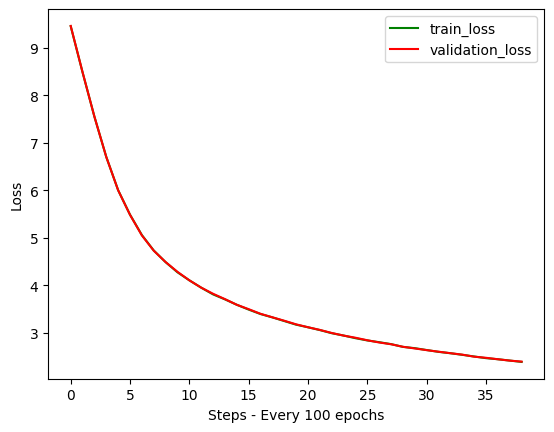

In [20]:
import matplotlib.pyplot as plt
train_loss_list_converted = [i.cpu().detach() for i in train_loss_list]
validation_loss_list_converted = [i.cpu().detach() for i in validation_loss_list]

plt.plot(train_loss_list_converted, 'g', label='train_loss')
plt.plot(validation_loss_list_converted, 'r', label='validation_loss')
plt.xlabel("Steps - Every 100 epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

## Step 10: Run SLM Inference on our trained model

In [21]:
#Load the model
model = GPT(config)  # re-create the model with same config
device =  "cuda" if torch.cuda.is_available() else "cpu"
best_model_params_path = "best_model_params.pt"
model.load_state_dict(torch.load(best_model_params_path, map_location=torch.device(device))) # load best model states


<All keys matched successfully>

In [22]:
sentence = "Once upon a time there was a pumpkin."
context = (torch.tensor(enc.encode_ordinary(sentence)).unsqueeze(dim = 0))
y = model.generate(context, 200)
print(enc.decode(y.squeeze().tolist()))

Once upon a time there was a pumpkin. All the other looking for something to eat, so she decided to eat something. She was having so many fun with all these crunchy fruit. But the pie made them enough, Sammy a smaller crayon in the pieces.

Ellie's friends laughed and but they did not know why they were nearby or the sandwich might brushed them all. He thought it sounds funny, but Johnny said: " wider, terrible shark, apples are both all together. We'm happy to have ever tasted later." But he lasted a few playing bubble melives, he lay down and it made Lucy happy too!Once upon a time there was a happy little girl. She loved to explore the park with her friends. One day she called an old woman, wearing an x, a small arm with her hands. It had a open younger mug from it.

The little girl was so excited to open it from the stove. After a while, she was so excited!

The lady slowly


In [23]:
sentence = "A little girl went to the woods"
context = (torch.tensor(enc.encode_ordinary(sentence)).unsqueeze(dim = 0))
y = model.generate(context, 200)
print(enc.decode(y.squeeze().tolist()))

A little girl went to the woods. Inside, there was a magical plane! It was her very special leading her time. 

When she got there there, the very special middle of the rocket cake made her day up, and on it had dinner. On the most amazing year old and everyone in the nearby house were making the perfect surprise they had ever seen.Once there was a little girl named Lucy. Lucy was very glad to organize the rare room. She put in her favorite toy box, but one day it couldn't go there to her room.

The girl said to the smiling.

Then she asked her mom for a surprise for the herb in the living room. This one was a blue's. Lucy was so excited - that she asked toys in the living room! She wanted makeup too!

The board smelled restaurant every day, Lily went to a box and told her mom all about candy looking with the avocado. Even the mixture glow, Sue smiled and said, "Mike, I


In [9]:
# RecipeNLG fine-tuning stage (after TinyStories pretraining)
import os
import re
import numpy as np
import torch
from tqdm.auto import tqdm
from torch.optim.lr_scheduler import LinearLR, SequentialLR, CosineAnnealingLR
from contextlib import nullcontext

def load_recipe_blocks(path):
    with open(path, "r", encoding="utf-8") as f:
        text = f.read()
    blocks = re.findall(r"<RECIPE>.*?</RECIPE>", text, flags=re.S)
    blocks = [b.strip() for b in blocks if b.strip()]
    if not blocks:
        raise ValueError(f"No recipe blocks found in {path}")
    return blocks

recipe_train_texts = load_recipe_blocks("recipe_train.txt")
recipe_valid_texts = load_recipe_blocks("recipe_valid.txt")

if "enc" not in globals():
    import tiktoken
    enc = tiktoken.get_encoding("gpt2")

# Ensure model classes/config exist for resume-only runs
if "GPT" not in globals():
    raise RuntimeError("GPT class not found. Run the Step 4 model architecture cell first.")
if "config" not in globals():
    if "GPTConfig" not in globals():
        raise RuntimeError("GPTConfig not found. Run the Step 4 model architecture cell first.")
    config = GPTConfig(
        vocab_size=50257,
        block_size=128,
        n_layer=6,
        n_head=6,
        n_embd=384,
        dropout=0.1,
        bias=True,
    )
if "model" not in globals():
    model = GPT(config)

if "block_size" not in globals():
    block_size = config.block_size
if "batch_size" not in globals():
    batch_size = 32
if "gradient_accumulation_steps" not in globals():
    gradient_accumulation_steps = 16

RECIPE_VERIFY_BINS = True  # set False to skip size verification
def encode_texts_to_memmap(texts, bin_path, desc):
    if os.path.exists(bin_path) and not RECIPE_VERIFY_BINS:
        return
    if not texts:
        raise ValueError(f"No texts available for {desc}")
    total_len = 0
    for text in tqdm(texts, desc=f"counting {desc}"):
        total_len += len(enc.encode_ordinary(text))
    expected_bytes = total_len * np.dtype(np.uint16).itemsize
    if os.path.exists(bin_path):
        if os.path.getsize(bin_path) == expected_bytes:
            return
        os.remove(bin_path)
    arr = np.memmap(bin_path, dtype=np.uint16, mode="w+", shape=(total_len,))
    idx = 0
    for text in tqdm(texts, desc=f"writing {desc}"):
        ids = enc.encode_ordinary(text)
        arr[idx : idx + len(ids)] = ids
        idx += len(ids)
    arr.flush()

encode_texts_to_memmap(recipe_train_texts, "recipe_train.bin", "recipe train")
encode_texts_to_memmap(recipe_valid_texts, "recipe_validation.bin", "recipe validation")

device = "cuda" if torch.cuda.is_available() else "cpu"
device_type = "cuda" if "cuda" in device else "cpu"
model = model.to(device)

if "dtype" not in globals():
    dtype = "bfloat16" if torch.cuda.is_available() and torch.cuda.is_bf16_supported() else "float16"
if "ptdtype" not in globals():
    ptdtype = {"float32": torch.float32, "bfloat16": torch.bfloat16, "float16": torch.float16}[dtype]
if "ctx" not in globals():
    ctx = nullcontext() if device_type == "cpu" else torch.amp.autocast(device_type=device_type, dtype=ptdtype)

def get_recipe_batch(split):
    data_path = "recipe_train.bin" if split == "train" else "recipe_validation.bin"
    data = np.memmap(data_path, dtype=np.uint16, mode="r")
    if len(data) <= block_size:
        raise ValueError("Recipe dataset is too small for the current block_size.")
    ix = torch.randint(len(data) - block_size, (batch_size,))
    x = torch.stack([torch.from_numpy((data[i:i+block_size]).astype(np.int64)) for i in ix])
    y = torch.stack([torch.from_numpy((data[i+1:i+1+block_size]).astype(np.int64)) for i in ix])
    if device_type == "cuda":
        x, y = x.pin_memory().to(device, non_blocking=True), y.pin_memory().to(device, non_blocking=True)
    else:
        x, y = x.to(device), y.to(device)
    return x, y

recipe_learning_rate = 5e-5
recipe_max_iters = 3000
recipe_warmup_steps = 200
recipe_min_lr = 1e-5
recipe_eval_interval = 200
recipe_eval_iters = 200
recipe_grad_accum = gradient_accumulation_steps if "gradient_accumulation_steps" in globals() else 16

recipe_optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=recipe_learning_rate,
    betas=(0.9, 0.95),
    weight_decay=0.1,
    eps=1e-9,
 )
recipe_scheduler_warmup = LinearLR(recipe_optimizer, total_iters=recipe_warmup_steps)
recipe_scheduler_decay = CosineAnnealingLR(
    recipe_optimizer,
    T_max=max(recipe_max_iters - recipe_warmup_steps, 1),
    eta_min=recipe_min_lr,
 )
recipe_scheduler = SequentialLR(
    recipe_optimizer,
    schedulers=[recipe_scheduler_warmup, recipe_scheduler_decay],
    milestones=[recipe_warmup_steps],
 )
recipe_scaler = torch.cuda.amp.GradScaler(enabled=(dtype == "float16"))

def estimate_recipe_loss(model):
    out = {}
    model.eval()
    with torch.inference_mode():
        for split in ["train", "val"]:
            losses = torch.zeros(recipe_eval_iters)
            for k in range(recipe_eval_iters):
                X, Y = get_recipe_batch(split)
                with ctx:
                    logits, loss = model(X, Y)
                losses[k] = loss.item()
            out[split] = losses.mean()
    model.train()
    return out

recipe_best_val_loss = float("inf")
recipe_ckpt_path = "recipe_finetuned.pt"
recipe_train_losses, recipe_val_losses = [], []
resume_recipe = True

if resume_recipe and os.path.exists(recipe_ckpt_path):
    model.load_state_dict(torch.load(recipe_ckpt_path, map_location=torch.device(device)))
elif os.path.exists("best_model_params.pt"):
    model.load_state_dict(torch.load("best_model_params.pt", map_location=torch.device(device)))

model.train()
for step in tqdm(range(recipe_max_iters)):
    if step % recipe_eval_interval == 0 and step != 0:
        losses = estimate_recipe_loss(model)
        print(f"Recipe step {step}: train {losses['train']:.4f}, val {losses['val']:.4f}")
        recipe_train_losses.append(losses["train"])
        recipe_val_losses.append(losses["val"])
        if losses["val"] < recipe_best_val_loss:
            recipe_best_val_loss = losses["val"]
            torch.save(model.state_dict(), recipe_ckpt_path)

    X, Y = get_recipe_batch("train")
    with ctx:
        logits, loss = model(X, Y)
        loss = loss / recipe_grad_accum
        recipe_scaler.scale(loss).backward()

    if ((step + 1) % recipe_grad_accum == 0) or (step + 1 == recipe_max_iters):
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=0.5)
        recipe_scaler.step(recipe_optimizer)
        recipe_scaler.update()
        recipe_optimizer.zero_grad(set_to_none=True)
    recipe_scheduler.step()

if os.path.exists(recipe_ckpt_path):
    model.load_state_dict(torch.load(recipe_ckpt_path, map_location=torch.device(device)))
model.eval()

temperature = 0.9
top_k = 50
max_new_tokens = 200

def generate_recipe(prompt):
    context = torch.tensor(enc.encode_ordinary(prompt), device=device).unsqueeze(0)
    y = model.generate(context, max_new_tokens=max_new_tokens, temperature=temperature, top_k=top_k)
    return enc.decode(y.squeeze().tolist())

recipe_prompts = [
    "<RECIPE>\n\nTitle: Garlic Pasta\n\nIngredients:\n",
    "<RECIPE>\n\nTitle: Spicy Paneer Curry\n\nIngredients:\n",
 ]

for prompt in recipe_prompts:
    print(generate_recipe(prompt))
    print("-" * 40)

counting recipe validation: 100%|██████████| 40957/40957 [00:04<00:00, 8933.12it/s]
C:\Users\LOQ\AppData\Local\Temp\ipykernel_20444\2674831407.py:127: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  recipe_scaler = torch.cuda.amp.GradScaler(enabled=(dtype == "float16"))
  0%|          | 0/3000 [00:00<?, ?it/s]c:\Users\LOQ\Desktop\Vizuara\.venv\Lib\site-packages\torch\optim\lr_scheduler.py:182: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  warnings.warn(
  7%|▋         | 199/3000 [00:28<05:55,  7.88it/s]c:\Users\LOQ\Desktop\Vizuara\.venv\Lib\site-packages\torch\optim\

Recipe step 200: train 6.5642, val 6.5631


 13%|█▎        | 400/3000 [01:14<05:26,  7.97it/s]  

Recipe step 400: train 5.7460, val 5.7428


 20%|██        | 600/3000 [01:59<04:55,  8.13it/s]  

...

Recipe step 2600: train 3.9616, val 3.9443


 93%|█████████▎| 2800/3000 [10:03<00:25,  7.81it/s]

Recipe step 2800: train 3.9324, val 3.9418


100%|██████████| 3000/3000 [10:46<00:00,  4.64it/s]


<RECIPE>

Title: Garlic Pasta

Ingredients:
- 2 Tbsp. chopped cheese
- 1/2- 1/2 teaspoon apple, crushed
- 1/2 teaspoon butter
- 2/4 teaspoon celery
- a large apple oil
- 2 cups water
- 1/4 dough onion, sliced
- 1 cup all-8 butter
- 1/2 butter
- 2 flour
- 5 cups milk
- 2 ingredients

Instructions:
1. Let add the sugar to the oven as they are hot.
2.
2. Add the egg and dry the sugar.
3. Baked the eggs and mix until it is smooth and sour.
t. Put in the pan and cook until the dough is done and it's no longer heavy and then roll over the oven.
12. Brown the sugar, the salt, sugar, and orange juice.
4. This is very dry and we should have to give it a very dry.

</RECIPE>
----------------------------------------
<RECIPE>

Title: Spicy Paneer Curry

Ingredients:
- 2 c. oil
- 1 c. milk
- 1/4 c. milk
- 1/4 c. salt
- 1 can dried pecans, chopped
- 1 egg

Instructions:
1. Once salt is brown, add a long stick sugar and sugar until golden brown.
3. Use a few oil and cut out of the dough.
4. Add the c

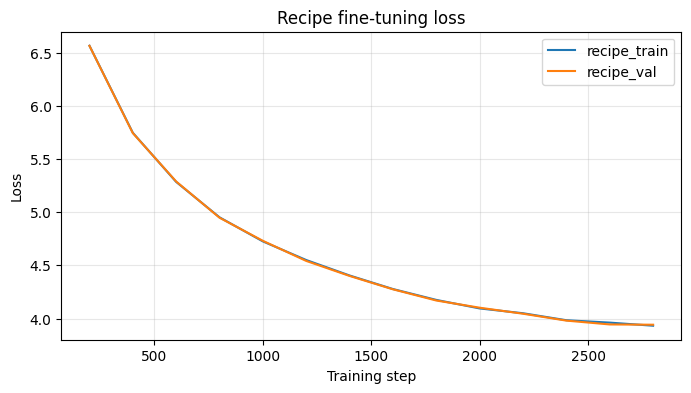

In [10]:
import matplotlib.pyplot as plt

if "recipe_train_losses" not in globals() or "recipe_val_losses" not in globals():
    raise RuntimeError("Fine-tuning loss lists not found. Run the fine-tuning cell first.")
if len(recipe_train_losses) == 0 and len(recipe_val_losses) == 0:
    raise RuntimeError("No fine-tuning losses recorded yet. Run the fine-tuning loop to collect losses.")

def _to_float_list(values):
    out = []
    for v in values:
        if hasattr(v, "item"):
            out.append(float(v.item()))
        else:
            out.append(float(v))
    return out

train_vals = _to_float_list(recipe_train_losses)
val_vals = _to_float_list(recipe_val_losses)

train_steps = [recipe_eval_interval * (i + 1) for i in range(len(train_vals))]
val_steps = [recipe_eval_interval * (i + 1) for i in range(len(val_vals))]

plt.figure(figsize=(8, 4))
if train_vals:
    plt.plot(train_steps, train_vals, label="recipe_train")
if val_vals:
    plt.plot(val_steps, val_vals, label="recipe_val")
plt.xlabel("Training step")
plt.ylabel("Loss")
plt.title("Recipe fine-tuning loss")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

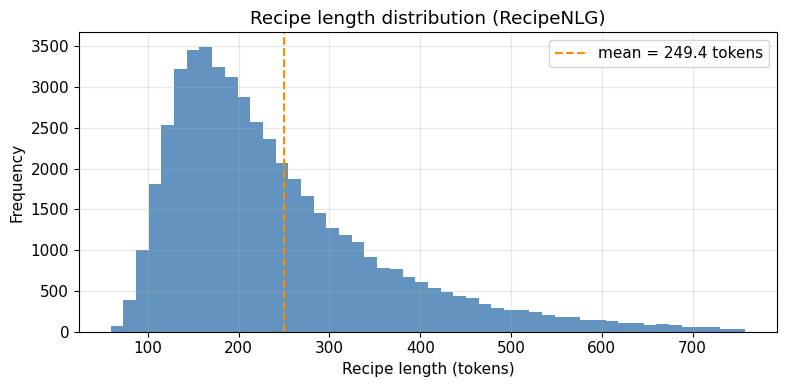

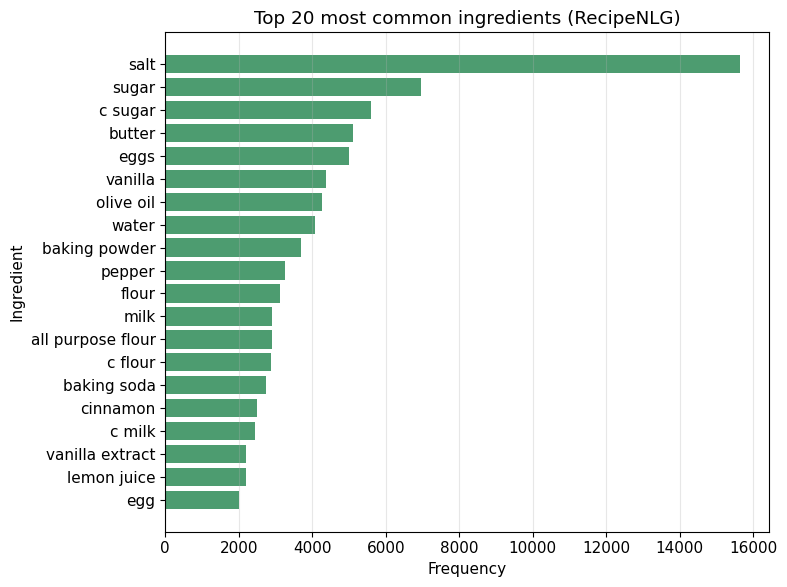

TinyStories loss lists not found. Run the pretraining loop first.


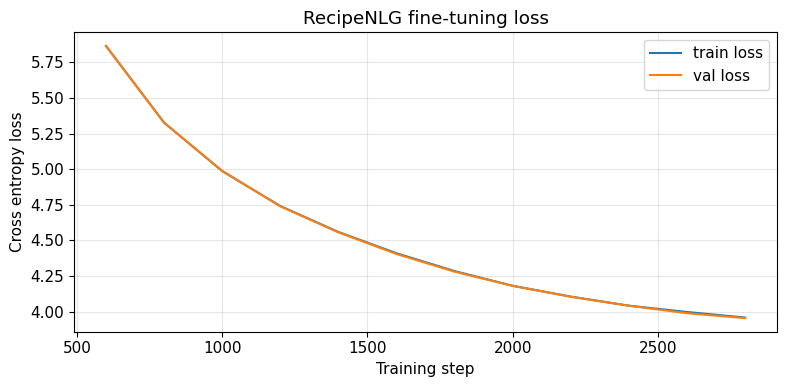

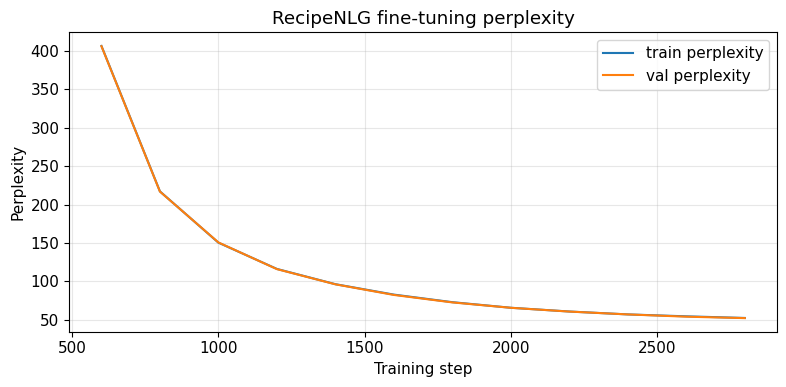

TinyStories LR config not found. Run training config cells first.


c:\Users\LOQ\Desktop\Vizuara\.venv\Lib\site-packages\torch\optim\lr_scheduler.py:198: UserWarning: The epoch parameter in `scheduler.step()` was not necessary and is being deprecated where possible. Please use `scheduler.step()` to step the scheduler. During the deprecation, if epoch is different from None, the closed form is used instead of the new chainable form, where available. Please open an issue if you are unable to replicate your use case: https://github.com/pytorch/pytorch/issues/new/choose.
  warnings.warn(EPOCH_DEPRECATION_WARNING, UserWarning)


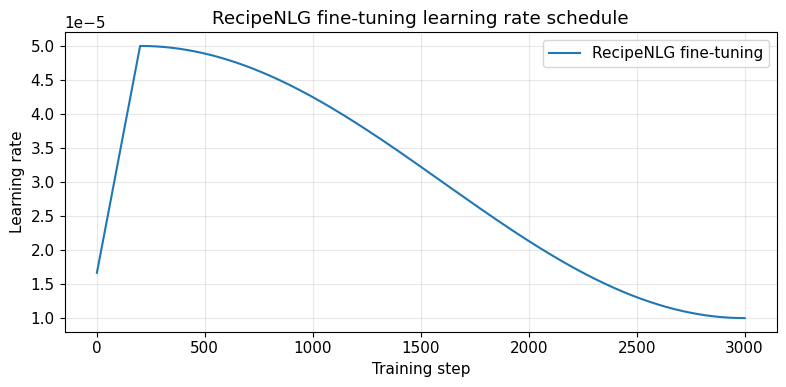

In [11]:
# Dataset analysis plots
import os
import re
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

plt.rcParams.update({"font.size": 11})

recipe_path = "recipe_train.txt"
if not os.path.exists(recipe_path):
    raise RuntimeError("recipe_train.txt not found. Run the RecipeNLG preprocessing cell first.")

def load_recipe_blocks_from_file(path):
    with open(path, "r", encoding="utf-8") as f:
        text = f.read()
    blocks = re.findall(r"<RECIPE>.*?</RECIPE>", text, flags=re.S)
    blocks = [b.strip() for b in blocks if b.strip()]
    if not blocks:
        raise ValueError(f"No recipe blocks found in {path}")
    return blocks

blocks = load_recipe_blocks_from_file(recipe_path)

MAX_RECIPES = 50000  # set None to use all recipes (can be slow)
if MAX_RECIPES is not None:
    blocks = blocks[:MAX_RECIPES]

use_tokens = False
tokenizer = None
if "enc" in globals():
    tokenizer = enc
    use_tokens = True
else:
    try:
        import tiktoken
        tokenizer = tiktoken.get_encoding("gpt2")
        use_tokens = True
    except Exception:
        tokenizer = None
        use_tokens = False

length_unit = "tokens" if use_tokens else "words"

def recipe_length(block):
    if tokenizer is None:
        return len(block.split())
    return len(tokenizer.encode_ordinary(block))

recipe_lengths = [recipe_length(b) for b in blocks]
mean_len = float(np.mean(recipe_lengths))
p99 = float(np.percentile(recipe_lengths, 99))
lengths_plot = [x for x in recipe_lengths if x <= p99]

plt.figure(figsize=(8, 4))
plt.hist(lengths_plot, bins=50, color="steelblue", alpha=0.85)
plt.axvline(mean_len, color="darkorange", linestyle="--", label=f"mean = {mean_len:.1f} {length_unit}")
plt.title("Recipe length distribution (RecipeNLG)")
plt.xlabel(f"Recipe length ({length_unit})")
plt.ylabel("Frequency")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

_units = [
    "cup", "cups", "tbsp", "tablespoon", "tablespoons", "tsp", "teaspoon", "teaspoons",
    "oz", "ounce", "ounces", "lb", "pound", "pounds", "g", "gram", "grams", "kg",
    "ml", "l", "pinch", "clove", "cloves", "slice", "slices", "can", "cans",
    "package", "packages", "stick", "sticks"
 ]
_units_pattern = r"^(?:" + "|".join(_units) + r")\b\s*"
_paren_re = re.compile(r"\([^)]*\)")
_nonword_re = re.compile(r"[^a-z0-9\s]")
_leading_amount_re = re.compile(r"^[\d\s\/\.\-]+")
_space_re = re.compile(r"\s{2,}")

def normalize_ingredient(text):
    text = text.lower().strip()
    text = _paren_re.sub(" ", text)
    text = text.replace(",", " ")
    text = _nonword_re.sub(" ", text)
    text = _leading_amount_re.sub("", text)
    text = re.sub(_units_pattern, "", text)
    text = _space_re.sub(" ", text).strip()
    return text

def extract_ingredients(block):
    match = re.search(r"Ingredients:\s*(.*?)\s*Instructions:", block, flags=re.S | re.I)
    if not match:
        return []
    lines = [ln.strip() for ln in match.group(1).splitlines() if ln.strip()]
    items = []
    for line in lines:
        line = line.lstrip("-").strip()
        if line:
            items.append(line)
    return items

counts = Counter()
for block in blocks:
    for item in extract_ingredients(block):
        norm = normalize_ingredient(item)
        if norm:
            counts[norm] += 1

top = counts.most_common(20)
if not top:
    raise RuntimeError("No ingredients found. Check recipe formatting.")

labels = [t[0] for t in top][::-1]
freqs = [t[1] for t in top][::-1]

plt.figure(figsize=(8, 6))
plt.barh(labels, freqs, color="seagreen", alpha=0.85)
plt.title("Top 20 most common ingredients (RecipeNLG)")
plt.xlabel("Frequency")
plt.ylabel("Ingredient")
plt.grid(True, axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

# Training dynamics plots
import math
import torch
from torch.optim.lr_scheduler import LinearLR, SequentialLR, CosineAnnealingLR

def _to_float_list(values):
    out = []
    for v in values:
        if hasattr(v, "item"):
            out.append(float(v.item()))
        else:
            out.append(float(v))
    return out

def _smooth_series(values, steps, window):
    if window <= 1 or len(values) < window:
        return values, steps
    kernel = np.ones(window) / float(window)
    smoothed = np.convolve(values, kernel, mode="valid")
    return smoothed, steps[window - 1 :]

def _plot_loss_curves(title, train_losses, val_losses, eval_interval, smooth_window=1):
    train_vals = _to_float_list(train_losses)
    val_vals = _to_float_list(val_losses)
    if len(train_vals) == 0 and len(val_vals) == 0:
        print(f"No loss values available for {title}.")
        return
    train_steps = [eval_interval * (i + 1) for i in range(len(train_vals))] if eval_interval else list(range(1, len(train_vals) + 1))
    val_steps = [eval_interval * (i + 1) for i in range(len(val_vals))] if eval_interval else list(range(1, len(val_vals) + 1))
    train_plot, train_steps = _smooth_series(train_vals, train_steps, smooth_window)
    val_plot, val_steps = _smooth_series(val_vals, val_steps, smooth_window)
    plt.figure(figsize=(8, 4))
    if len(train_plot) > 0:
        plt.plot(train_steps, train_plot, label="train loss")
    if len(val_plot) > 0:
        plt.plot(val_steps, val_plot, label="val loss")
    plt.title(f"{title} loss")
    plt.xlabel("Training step")
    plt.ylabel("Cross entropy loss")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

# Evaluation plots (perplexity)
def _plot_ppl_curves(title, train_losses, val_losses, eval_interval, smooth_window=1):
    train_vals = _to_float_list(train_losses)
    val_vals = _to_float_list(val_losses)
    if len(train_vals) == 0 and len(val_vals) == 0:
        print(f"No perplexity values available for {title}.")
        return
    train_steps = [eval_interval * (i + 1) for i in range(len(train_vals))] if eval_interval else list(range(1, len(train_vals) + 1))
    val_steps = [eval_interval * (i + 1) for i in range(len(val_vals))] if eval_interval else list(range(1, len(val_vals) + 1))
    train_ppl = np.exp(np.clip(train_vals, -20, 20))
    val_ppl = np.exp(np.clip(val_vals, -20, 20))
    train_plot, train_steps = _smooth_series(train_ppl, train_steps, smooth_window)
    val_plot, val_steps = _smooth_series(val_ppl, val_steps, smooth_window)
    plt.figure(figsize=(8, 4))
    if len(train_plot) > 0:
        plt.plot(train_steps, train_plot, label="train perplexity")
    if len(val_plot) > 0:
        plt.plot(val_steps, val_plot, label="val perplexity")
    plt.title(f"{title} perplexity")
    plt.xlabel("Training step")
    plt.ylabel("Perplexity")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

SMOOTH_WINDOW = 3

if "train_loss_list" in globals() and "validation_loss_list" in globals():
    pre_eval_interval = eval_iters if "eval_iters" in globals() else 1
    _plot_loss_curves("TinyStories pretraining", train_loss_list, validation_loss_list, pre_eval_interval, SMOOTH_WINDOW)
    _plot_ppl_curves("TinyStories pretraining", train_loss_list, validation_loss_list, pre_eval_interval, SMOOTH_WINDOW)
else:
    print("TinyStories loss lists not found. Run the pretraining loop first.")

if "recipe_train_losses" in globals() and "recipe_val_losses" in globals():
    ft_eval_interval = recipe_eval_interval if "recipe_eval_interval" in globals() else 1
    _plot_loss_curves("RecipeNLG fine-tuning", recipe_train_losses, recipe_val_losses, ft_eval_interval, SMOOTH_WINDOW)
    _plot_ppl_curves("RecipeNLG fine-tuning", recipe_train_losses, recipe_val_losses, ft_eval_interval, SMOOTH_WINDOW)
else:
    print("Recipe fine-tuning loss lists not found. Run the fine-tuning loop first.")

# Optimization plots (learning rate schedule)
def simulate_lr_schedule(base_lr, warmup_steps, total_steps, min_lr):
    base_lr = float(base_lr)
    total_steps = int(total_steps)
    warmup_steps = int(warmup_steps)
    if total_steps <= 0:
        return []
    dummy = torch.nn.Parameter(torch.zeros(1, device="cpu"))
    opt = torch.optim.AdamW([dummy], lr=base_lr, betas=(0.9, 0.95), weight_decay=0.1, eps=1e-9)
    lrs = []
    if warmup_steps > 0:
        sched_warmup = LinearLR(opt, total_iters=warmup_steps)
        sched_decay = CosineAnnealingLR(opt, T_max=max(total_steps - warmup_steps, 1), eta_min=min_lr)
        sched = SequentialLR(opt, schedulers=[sched_warmup, sched_decay], milestones=[warmup_steps])
    else:
        sched = CosineAnnealingLR(opt, T_max=max(total_steps, 1), eta_min=min_lr)
    for _ in range(total_steps):
        lrs.append(opt.param_groups[0]["lr"])
        opt.step()
        sched.step()
    return lrs

def plot_lr_schedule(title, base_lr, warmup_steps, total_steps, min_lr):
    lrs = simulate_lr_schedule(base_lr, warmup_steps, total_steps, min_lr)
    if not lrs:
        print(f"No LR values available for {title}.")
        return
    steps = np.arange(1, len(lrs) + 1)
    plt.figure(figsize=(8, 4))
    plt.plot(steps, lrs, label=title)
    plt.title(f"{title} learning rate schedule")
    plt.xlabel("Training step")
    plt.ylabel("Learning rate")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

if all(name in globals() for name in ["learning_rate", "warmup_steps", "max_iters", "min_lr"]):
    plot_lr_schedule("TinyStories pretraining", learning_rate, warmup_steps, max_iters, min_lr)
else:
    print("TinyStories LR config not found. Run training config cells first.")

if all(name in globals() for name in ["recipe_learning_rate", "recipe_warmup_steps", "recipe_max_iters", "recipe_min_lr"]):
    plot_lr_schedule("RecipeNLG fine-tuning", recipe_learning_rate, recipe_warmup_steps, recipe_max_iters, recipe_min_lr)
else:
    print("Recipe LR config not found. Run the fine-tuning cell first.")